# IC diagnosis — the four-arm analyst board

**Board:** `reports/hk`, 11 analysts × 4 text arms, 2016-01 → 2026-06, Haiku, 5,528 records.

An IC is one number over ~125 observations. This notebook takes it apart. Order of the
argument:

1. **Ranked IC per analyst** — one figure per arm, deliberately not merged, so each arm
   is read on its own before any comparison.
2. **Ranked IC per tradeable asset** — the same read in instrument space, where a view
   has to reach a market rather than just describe the world.
3. **Scatter, fit, and outliers** — the actual joint distribution behind each
   correlation, with the special cases named by date so they can be read.
4. **Rolling IC** — is the skill stable, or one regime wearing a sample's clothes?
5. **The mean-IC table with margins** — analyst mean across arms, arm mean across
   analysts, so both the analyst *and the experiment* can be judged.
6. **The t-statistic itself** — how it is computed, what it assumes, and where those
   assumptions fail on this board.
7. **Alternative IC readings** the plan did not call for, and what they add.

Everything here is offline over saved runs, $0, and **must never inform a prompt** —
the honesty rule from `docs/analyst-layer.md` §6.

In [1]:
import sys, os, math, glob, warnings
warnings.filterwarnings("ignore")
sys.path.insert(0, os.path.abspath(".."))

import numpy as np, pandas as pd
import matplotlib as mpl, matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

from src.layered.evaluation.runs import load_run
from src.layered.evaluation import ic_diagnostics as D
from src.layered.evaluation.trade_pnl import forward_yield_change
from src.data.equity_local import load_any_bundle

BOARD = "../reports/hk"
ARMS  = ["none", "anon_cue", "anon_full", "plain"]   # ordered by text quantity
ARM_LABEL = {"none":"none — numbers only", "anon_cue":"anon_cue — driver extract",
             "anon_full":"anon_full — whole statement", "plain":"plain — un-anonymized (LEAK ARM)"}
RELEASE_CLOCK = {"inflation":124, "labor_tightness":124}

# ── palette (validated: run scripts/validate_palette.js on the categorical set) ──
SURFACE, INK, INK2, MUTED, GRID = "#fcfcfb", "#0b0b0b", "#52514e", "#898781", "#e1e0d9"
POS, NEG, NEUTRAL = "#2a78d6", "#e34948", "#f0efec"      # diverging: blue / red / gray
ARM_COLOR = dict(zip(ARMS, ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]))

mpl.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "font.family": "sans-serif", "font.size": 10,
    "text.color": INK, "axes.labelcolor": INK2, "xtick.color": MUTED, "ytick.color": MUTED,
    "axes.edgecolor": "#c3c2b7", "axes.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "grid.color": GRID, "grid.linewidth": 0.6, "axes.grid": False,
    "figure.dpi": 110, "axes.titlesize": 11, "axes.titleweight": "600",
    "axes.titlelocation": "left", "axes.titlepad": 10,
})

def bar_color(v):     return POS if v >= 0 else NEG
def clean(ax, xgrid=True):
    ax.grid(axis="x" if xgrid else "y", zorder=0)
    ax.set_axisbelow(True)
print("ready")

ready


## Load the board

One `Run` per (driver, arm). `signed` and `level` already exclude degraded views.

In [2]:
runs, meta = {}, []
for f in sorted(glob.glob(f"{BOARD}/*.jsonl")):
    stem = os.path.basename(f)[:-6]
    drv, arm = stem, ""
    for a in ARMS:
        if stem.endswith("_" + a): drv, arm = stem[:-(len(a)+1)], a; break
    r = load_run(f)
    runs[(drv, arm)] = r
    n, ic, t = D.rank_ic(*D.align(r.signed.dropna(), r.level.dropna())[["s","y"]].values.T) \
        if False else D.rank_ic(D.align(r.signed.dropna(), r.level.dropna())["s"],
                                D.align(r.signed.dropna(), r.level.dropna())["y"])
    meta.append({"driver": drv, "arm": arm, "n": n, "ic": ic, "t": t})

IC = pd.DataFrame(meta)
DRIVERS = sorted(IC["driver"].unique())
print(f"{len(runs)} legs · {len(DRIVERS)} analysts · arms {ARMS}")
IC.pivot_table(index="driver", columns="arm", values="ic")[ARMS].round(3)

44 legs · 11 analysts · arms ['none', 'anon_cue', 'anon_full', 'plain']


arm,none,anon_cue,anon_full,plain
driver,,,,
balance_sheet,0.623,0.655,0.695,0.732
curve_slope,0.050,0.282,0.124,0.096
financial_conditions,0.244,0.198,0.098,0.284
inflation,0.281,0.262,0.289,0.226
inflation_expectations,0.010,0.043,-0.108,-0.057
labor_tightness,0.074,0.153,0.137,0.118
positioning,-0.104,-0.084,0.055,-0.013
risk_appetite,0.171,0.147,0.088,0.066
sector_breadth,-0.221,-0.161,-0.176,-0.113


## 1 — Ranked IC per analyst, one figure per arm

Four separate figures on purpose. Merging them would invite reading across arms before
each has been read on its own, and the arms are not equally interpretable — `positioning`'s
`anon_cue` **is** its `none` arm (0% excerpt coverage), and `plain` is a leak probe whose IC
is not an analyst result.

Two reference lines on each: the dashed line is the IC that would give **t = 2** at this
sample size (~0.18 at n=125); the dotted line is **IC = 0.289**, the project's own
economic bar — the IC a single driver making ~12 bets a year needs for an information
ratio of 1.0. Statistical visibility and economic usefulness are different thresholds and
the plot shows both.

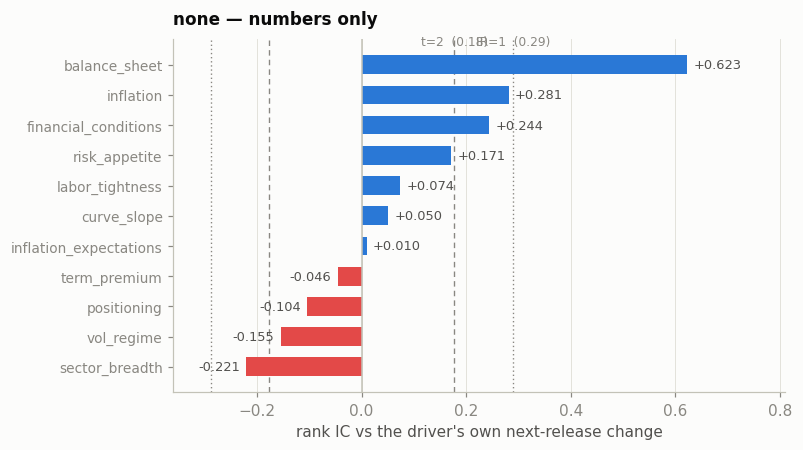

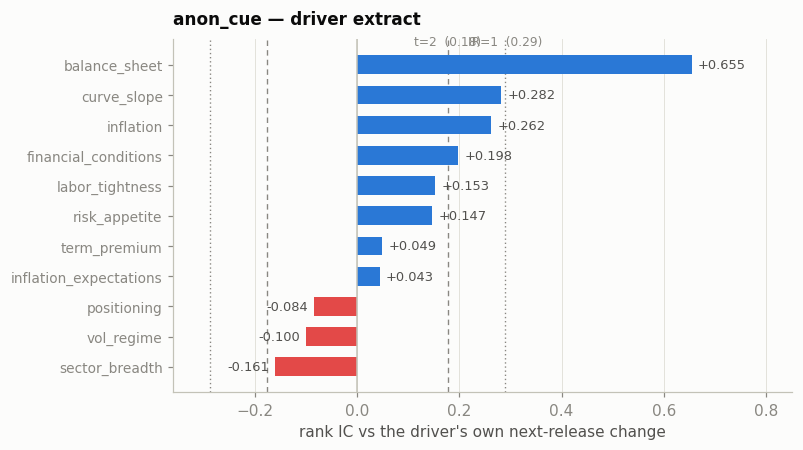

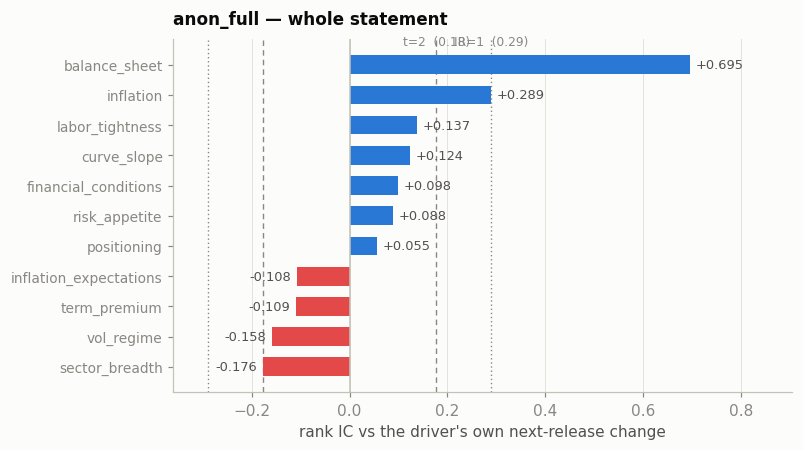

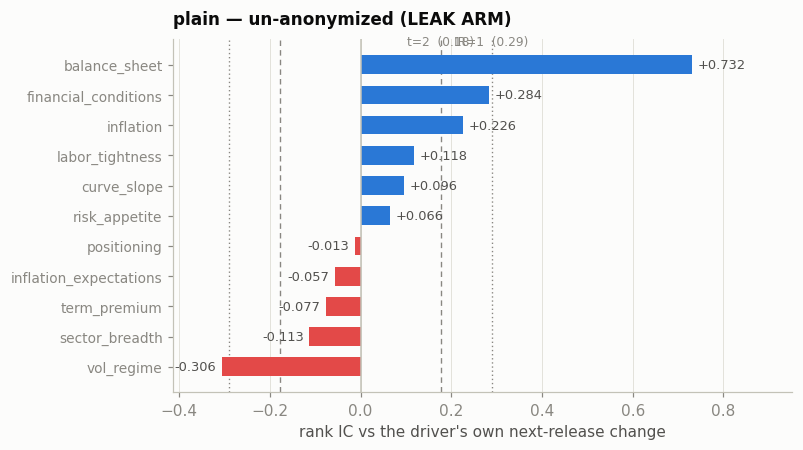

In [3]:
def plot_ranked_ic(arm, ax=None):
    d = IC[IC["arm"] == arm].sort_values("ic")
    ax = ax or plt.subplots(figsize=(7.4, 4.2))[1]
    y = np.arange(len(d))
    ax.barh(y, d["ic"], color=[bar_color(v) for v in d["ic"]], height=0.62, zorder=3)
    ax.set_yticks(y); ax.set_yticklabels(d["driver"], fontsize=9)
    n_med = int(d["n"].median())
    for x, ls, lab in ((D.ic_for_t(2, n_med), (0,(4,3)), f"t=2  ({D.ic_for_t(2,n_med):.2f})"),
                       (D.IR1_BAR, (0,(1,2)), f"IR=1  ({D.IR1_BAR:.2f})")):
        for sgn in (1, -1):
            ax.axvline(sgn*x, color=MUTED, lw=0.9, ls=ls, zorder=2)
        ax.text(x, len(d)-0.35, lab, color=MUTED, fontsize=8, ha="center")
    ax.axvline(0, color="#c3c2b7", lw=1.0, zorder=4)
    # direct labels — the relief rule, and they remove the need to read off the axis
    for yi, v in zip(y, d["ic"]):
        ax.text(v + (0.012 if v >= 0 else -0.012), yi, f"{v:+.3f}",
                va="center", ha="left" if v >= 0 else "right", fontsize=8.5, color=INK2)
    ax.set_xlim(min(-0.36, d["ic"].min()*1.35), max(0.42, d["ic"].max()*1.30))
    ax.set_xlabel("rank IC vs the driver's own next-release change")
    ax.set_title(f"{ARM_LABEL[arm]}", color=INK)
    clean(ax)
    return ax

for arm in ARMS:
    fig, ax = plt.subplots(figsize=(7.4, 4.2))
    plot_ranked_ic(arm, ax)
    plt.tight_layout(); plt.show()

## 2 — Ranked IC per tradeable asset

The primary IC grades an analyst on **its own driver** — did inflation actually rise? That
is the claim it was asked to make. It says nothing about whether the claim reaches a
market.

Here the same signed conviction is scored against the forward change in each instrument's
yield. No driver→instrument map is declared, deliberately: reporting every cell turns the
pods' `listens_to` polarity table into a *falsifiable prediction* about which cells should
light up, and a significant cell nobody predicted is more interesting than a confirmation.

Sign convention is `trade_pnl`'s: positive means a long view preceded the yield **rising**.
That is not a bond return.

In [4]:
INSTRUMENTS = ["DGS3MO", "DGS2", "DGS10", "T10YIE"]
macro_inst = load_any_bundle(INSTRUMENTS)

def instrument_ic_table(arm):
    rows = []
    for drv in DRIVERS:
        r = runs.get((drv, arm))
        if r is None: continue
        s = r.signed.dropna()
        if s.empty: continue
        freq = "B" if drv in RELEASE_CLOCK else "ME"
        fwd = forward_yield_change(macro_inst, INSTRUMENTS,
                                   pd.DatetimeIndex(s.index), steps=1, freq=freq)
        for inst in INSTRUMENTS:
            n, ic, t = D.rank_ic(s, fwd[inst])
            rows.append({"driver": drv, "instrument": inst, "n": n, "ic": ic, "t": t})
    return pd.DataFrame(rows)

INST = {arm: instrument_ic_table(arm) for arm in ARMS}
print("computed instrument-space IC for all four arms")

computed instrument-space IC for all four arms


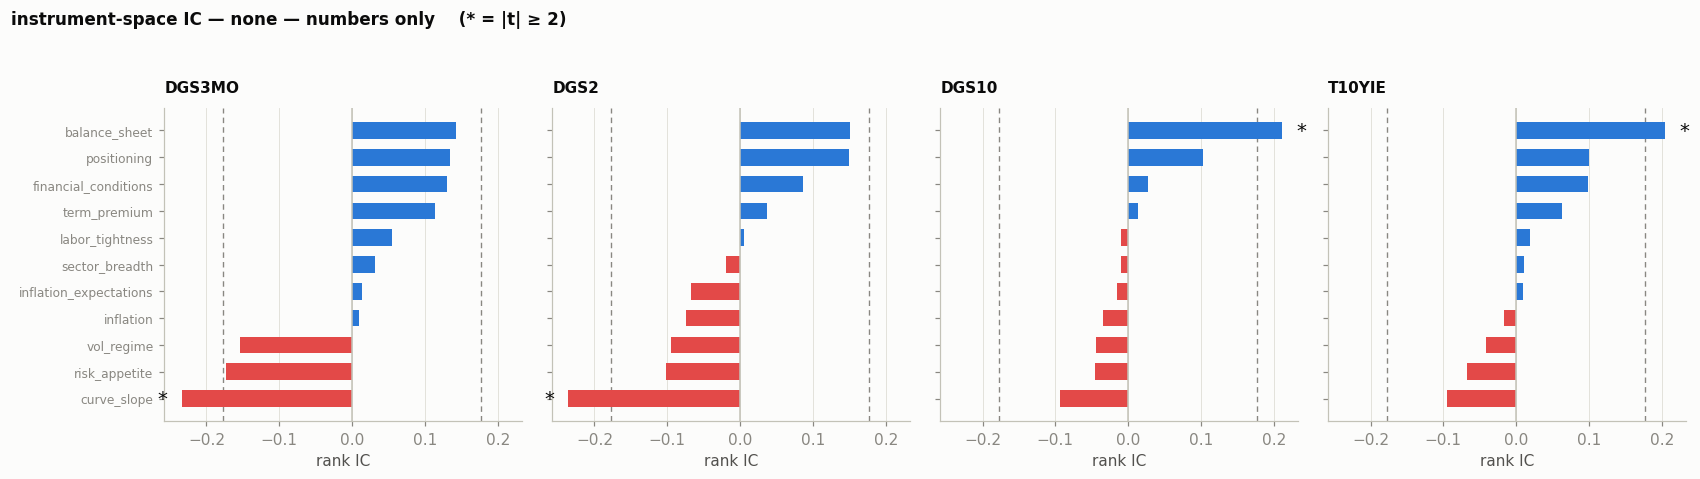

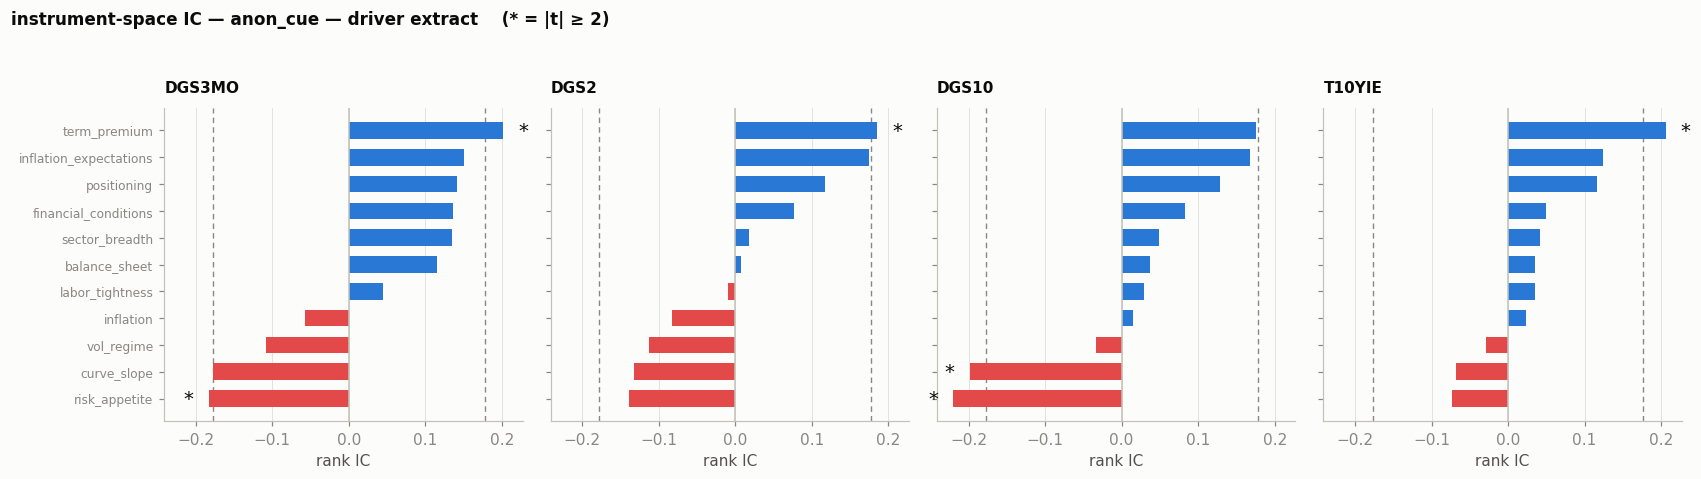

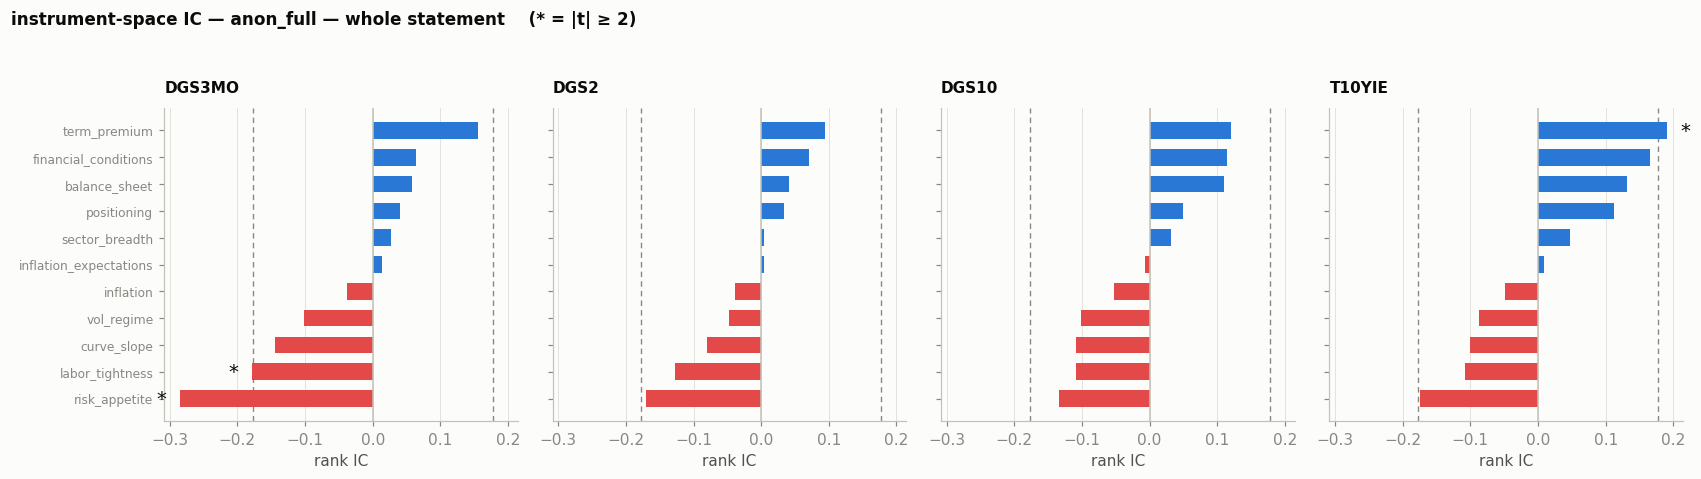

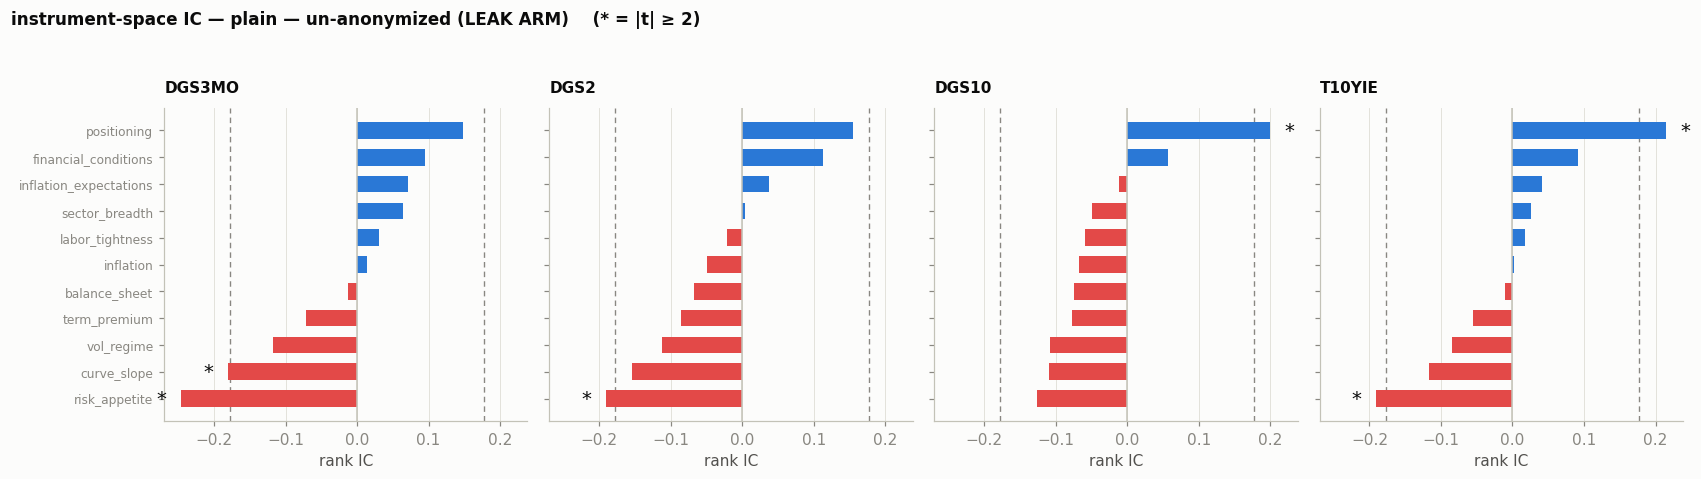

In [5]:
for arm in ARMS:
    d = INST[arm]
    fig, axes = plt.subplots(1, 4, figsize=(15.5, 4.4), sharex=True)
    for ax, inst in zip(axes, INSTRUMENTS):
        di = d[d["instrument"] == inst].sort_values("ic")
        y = np.arange(len(di))
        ax.barh(y, di["ic"], color=[bar_color(v) for v in di["ic"]], height=0.62, zorder=3)
        ax.set_yticks(y); ax.set_yticklabels(di["driver"] if inst == INSTRUMENTS[0] else [],
                                            fontsize=8)
        ax.axvline(0, color="#c3c2b7", lw=1.0, zorder=4)
        thr = D.ic_for_t(2, int(di["n"].median()))
        for sgn in (1,-1): ax.axvline(sgn*thr, color=MUTED, lw=0.9, ls=(0,(4,3)), zorder=2)
        # star the cells that clear |t|>=2, so the eye goes to them
        for yi, (v, tv) in enumerate(zip(di["ic"], di["t"])):
            if abs(tv) >= 2:
                ax.text(v + (0.02 if v>=0 else -0.02), yi, "*", va="center",
                        ha="left" if v>=0 else "right", fontsize=13, color=INK)
        ax.set_title(inst, color=INK, fontsize=10)
        ax.set_xlabel("rank IC")
        clean(ax)
    fig.suptitle(f"instrument-space IC — {ARM_LABEL[arm]}    (* = |t| ≥ 2)",
                 x=0.005, ha="left", fontsize=11, color=INK, weight="600")
    plt.tight_layout(rect=(0,0,1,0.94)); plt.show()

## 3 — The joint distribution behind each correlation

A rank IC of +0.30 and one of −0.30 can come from very different pictures. Each panel is
one analyst's signed conviction against the realized next-release change in its driver,
with an OLS fit.

**Outliers are flagged the standard way:** studentized residuals from that fit, using the
leave-one-out sigma so a point cannot mask itself, flagged at |t_i| > 2.5 and labelled with
their date. Marker *size* carries Cook's distance, which separates two things that need
different explanations — a high-leverage extreme call that was wrong, versus an ordinary
call that a freak move blindsided.

Read the flagged dates in `results/board/` or the raw reports; that is the point of naming
them.

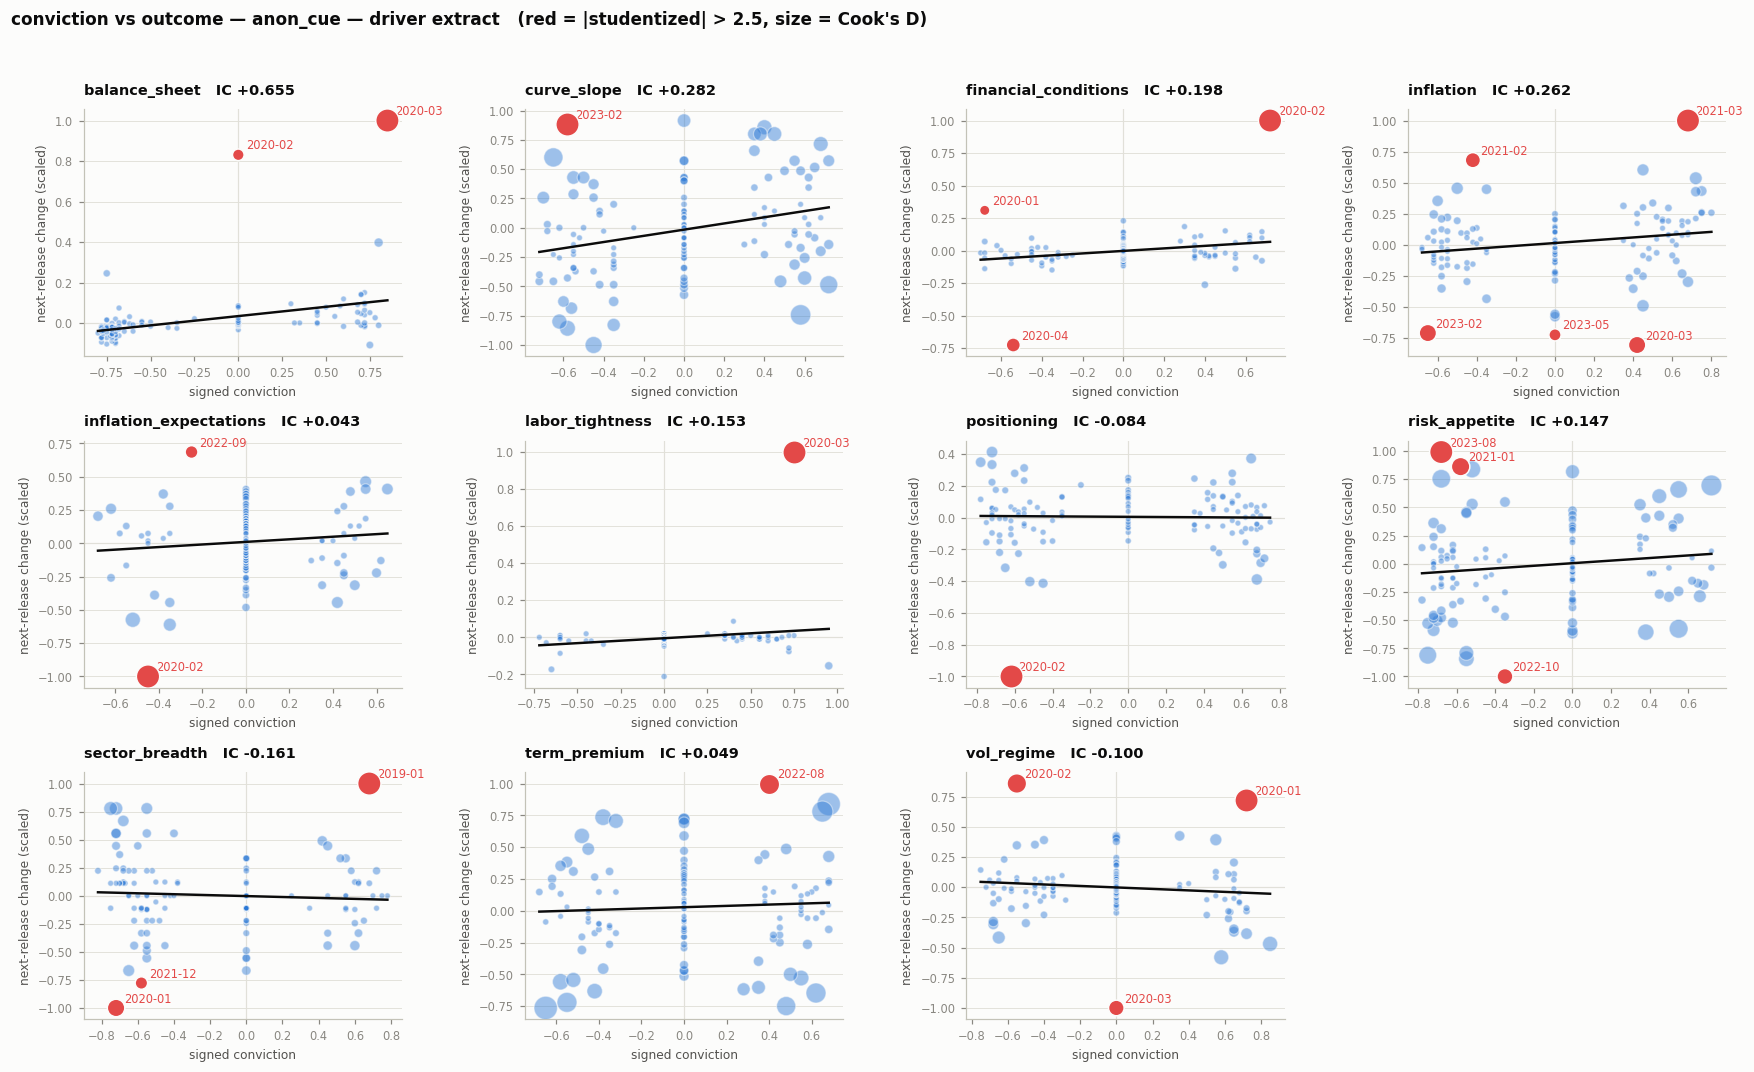

In [6]:
def plot_scatter_grid(arm, z=2.5, ncols=4):
    n = len(DRIVERS); nrows = math.ceil(n/ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.0*ncols, 3.3*nrows))
    axes = np.atleast_1d(axes).ravel()
    flagged = []
    for ax, drv in zip(axes, DRIVERS):
        r = runs.get((drv, arm))
        o = D.ic_outliers(r.signed.dropna(), r.level.dropna(), z=z) if r is not None else pd.DataFrame()
        if o.empty:
            ax.axis("off"); continue
        norm = o["outcome"].abs().max() or 1.0
        yy = o["outcome"]/norm                     # scale-free: driver units differ wildly
        fit = o["fitted"]/norm
        sz = 14 + 220*(o["cooks_d"]/max(1e-9, o["cooks_d"].max()))
        ok = ~o["is_outlier"]
        ax.scatter(o.loc[ok,"signed"], yy[ok], s=sz[ok], facecolor=POS, alpha=0.45,
                   edgecolor=SURFACE, linewidth=0.8, zorder=3)
        ax.scatter(o.loc[~ok,"signed"], yy[~ok], s=sz[~ok], facecolor=NEG,
                   edgecolor=SURFACE, linewidth=1.0, zorder=4)
        srt = o.sort_values("signed")
        ax.plot(srt["signed"], srt["fitted"]/norm, color=INK, lw=1.6, zorder=5)
        for d_, row in o[o["is_outlier"]].iterrows():
            ax.annotate(pd.Timestamp(d_).strftime("%Y-%m"),
                        (row["signed"], row["outcome"]/norm),
                        textcoords="offset points", xytext=(5,4), fontsize=7.5, color=NEG)
            flagged.append({"driver":drv,"arm":arm,"date":str(pd.Timestamp(d_).date()),
                            "signed":round(row["signed"],2),
                            "studentized":round(row["studentized"],2),
                            "leverage":round(row["leverage"],3),
                            "cooks_d":round(row["cooks_d"],3)})
        ax.axhline(0, color=GRID, lw=0.8); ax.axvline(0, color=GRID, lw=0.8)
        ic = IC[(IC.driver==drv)&(IC.arm==arm)]["ic"].iloc[0]
        ax.set_title(f"{drv}   IC {ic:+.3f}", fontsize=9.5, color=INK)
        ax.set_xlabel("signed conviction", fontsize=8)
        ax.set_ylabel("next-release change (scaled)", fontsize=8)
        ax.tick_params(labelsize=7.5); clean(ax, xgrid=False)
    for ax in axes[len(DRIVERS):]: ax.axis("off")
    fig.suptitle(f"conviction vs outcome — {ARM_LABEL[arm]}   "
                 f"(red = |studentized| > {z}, size = Cook's D)",
                 x=0.005, ha="left", fontsize=11, color=INK, weight="600")
    plt.tight_layout(rect=(0,0,1,0.96)); plt.show()
    return pd.DataFrame(flagged)

FLAGGED = plot_scatter_grid("anon_cue")

In [7]:
# The special cases, all arms — the list to actually go and read.
FLAGGED_ALL = pd.concat([D.ic_outliers(runs[(d,a)].signed.dropna(), runs[(d,a)].level.dropna())
                          .assign(driver=d, arm=a).query("is_outlier")
                         for d in DRIVERS for a in ARMS if (d,a) in runs], ignore_index=False)
FLAGGED_ALL = (FLAGGED_ALL.reset_index().rename(columns={"index":"date"})
               [["driver","arm","date","signed","outcome","studentized","leverage","cooks_d"]]
               .sort_values("cooks_d", ascending=False))
print(f"{len(FLAGGED_ALL)} flagged observations across {len(runs)} legs "
      f"({len(FLAGGED_ALL)/IC['n'].sum()*100:.2f}% of all observations)\n")
print("most influential dates, pooled across arms:")
display(FLAGGED_ALL.head(15).round(3))
print("\nwhich months dominate?")
display(FLAGGED_ALL.assign(month=lambda x: pd.to_datetime(x["date"]).dt.to_period("M").astype(str))
        .groupby("month").size().sort_values(ascending=False).head(8).rename("flags"))

98 flagged observations across 44 legs (1.79% of all observations)

most influential dates, pooled across arms:


,driver,arm,date,signed,outcome,studentized,leverage,cooks_d
52,labor_tightness,anon_cue,2020-03-08,0.75,10.400,29.436,0.039,2.173
53,labor_tightness,anon_full,2020-03-08,0.75,10.400,29.476,0.038,2.085
55,labor_tightness,plain,2020-03-08,0.75,10.400,29.478,0.037,2.033
50,labor_tightness,none,2020-03-08,0.78,10.400,29.834,0.034,1.877
14,financial_conditions,anon_cue,2020-02-29,0.72,0.608,9.595,0.041,1.132
19,financial_conditions,plain,2020-02-29,0.68,0.608,9.640,0.038,1.042
4,balance_sheet,anon_full,2020-03-31,0.75,1318858.000,9.736,0.037,1.024
2,balance_sheet,anon_cue,2020-03-31,0.85,1318858.000,9.721,0.035,0.975
6,balance_sheet,plain,2020-03-31,0.75,1318858.000,9.839,0.033,0.926
12,financial_conditions,none,2020-02-29,-0.72,0.608,10.517,0.031,0.921



which months dominate?


month
2020-02    21
2020-03    16
2020-01    10
2022-08     7
2023-02     5
2019-01     4
2021-03     4
2022-10     4
Name: flags, dtype: int64

## 4 — Rolling IC

24-observation trailing window (two years on a monthly clock), one panel per analyst, the
four arms as lines. At n=24 the IC needed for t=2 is ~0.39 — drawn as the dashed band — so
read the **shape and the sign persistence**, not whether a point clears a line. A rolling
*t* would carry the same information rescaled by a constant while inviting exactly that
misreading; `D.rolling_t` exists but its docstring argues against using it.

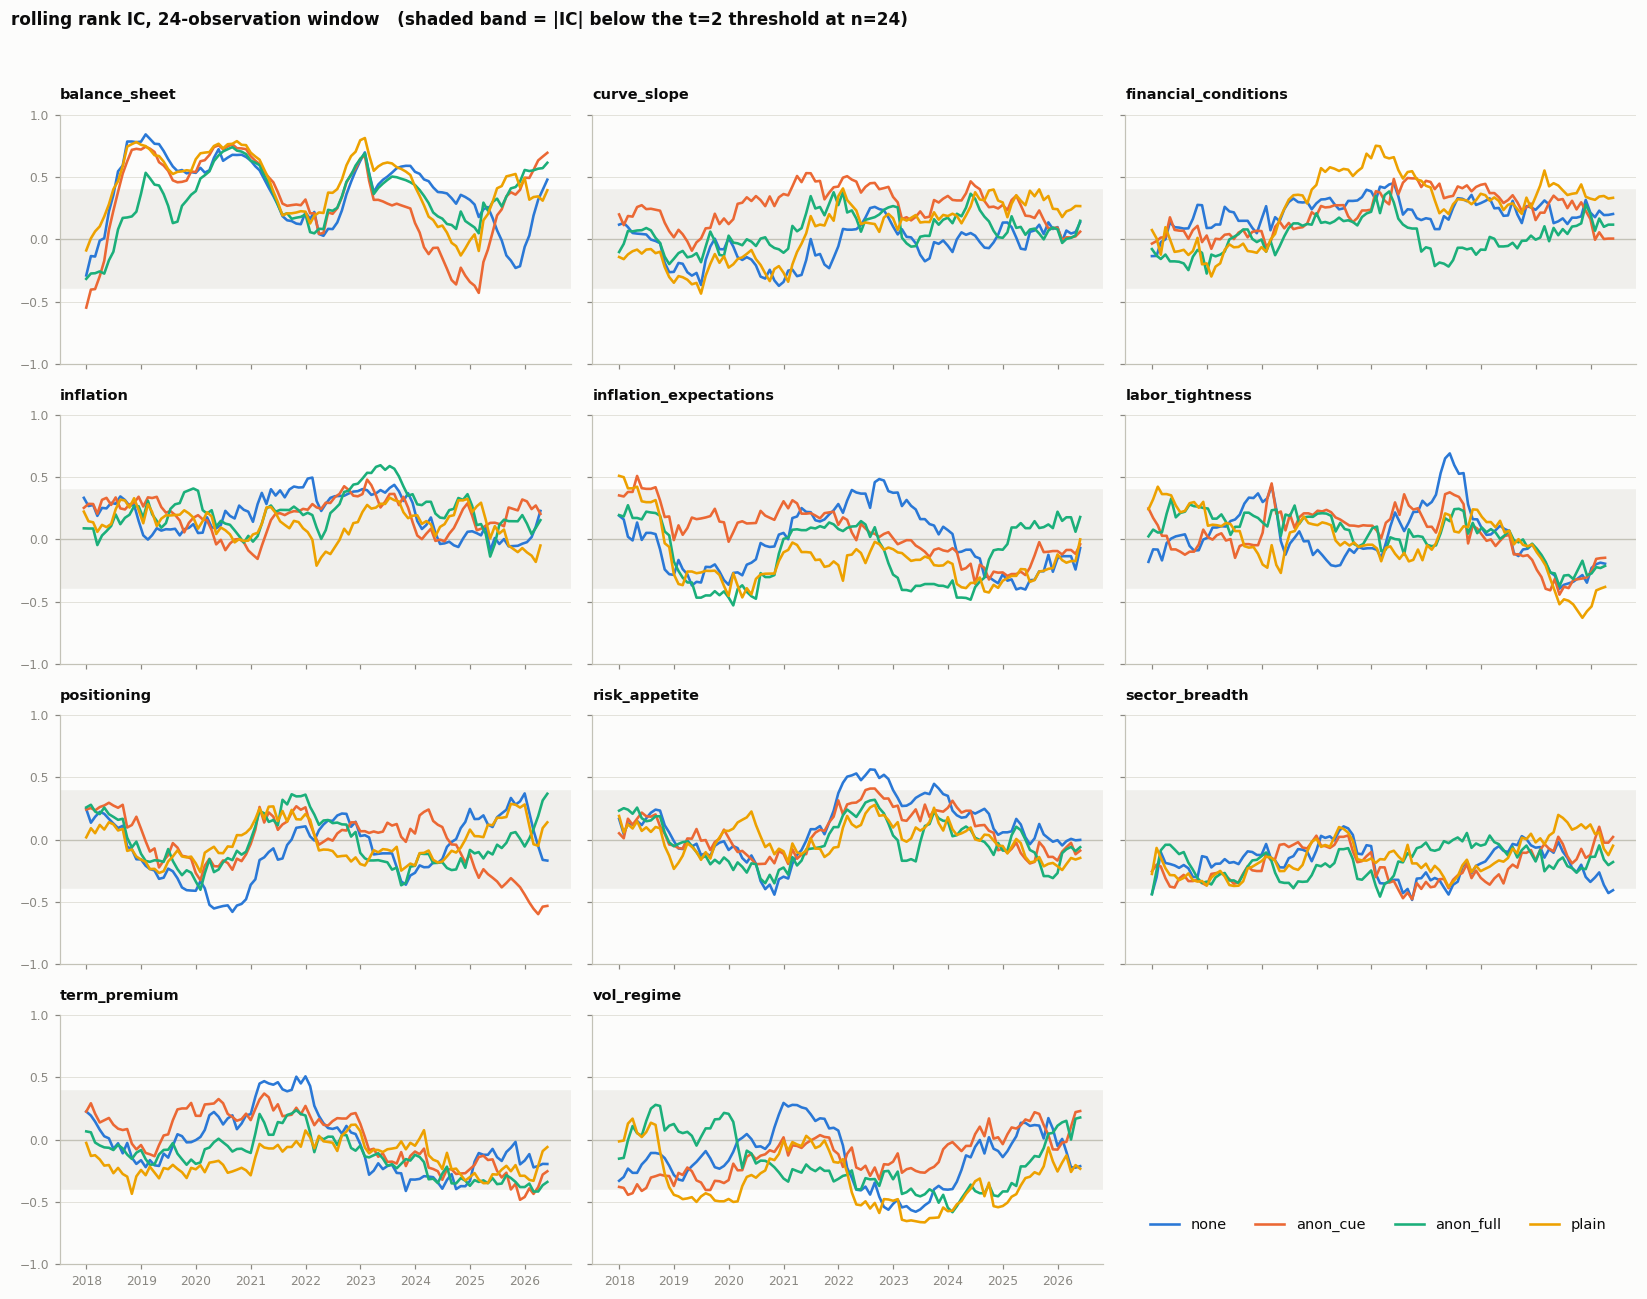

In [8]:
WINDOW = 24
thr24 = D.ic_for_t(2, WINDOW)
fig, axes = plt.subplots(4, 3, figsize=(15, 12), sharex=True, sharey=True)
axes = axes.ravel()
for ax, drv in zip(axes, DRIVERS):
    for arm in ARMS:
        r = runs.get((drv, arm))
        if r is None: continue
        ric = D.rolling_ic(r.signed.dropna(), r.level.dropna(), window=WINDOW)
        if ric.empty: continue
        ax.plot(ric.index, ric.values, color=ARM_COLOR[arm], lw=1.7, label=arm, zorder=3)
    ax.axhspan(-thr24, thr24, color=NEUTRAL, zorder=1)
    ax.axhline(0, color="#c3c2b7", lw=0.9, zorder=2)
    ax.set_title(drv, fontsize=9.5, color=INK)
    ax.set_ylim(-1, 1); ax.tick_params(labelsize=8)
    ax.yaxis.set_major_locator(MultipleLocator(0.5)); clean(ax, xgrid=False)
for ax in axes[len(DRIVERS):]: ax.axis("off")
h, l = axes[0].get_legend_handles_labels()
fig.legend(h, l, loc="lower right", frameon=False, ncols=4, fontsize=9.5,
           bbox_to_anchor=(0.98, 0.045))
fig.suptitle(f"rolling rank IC, {WINDOW}-observation window   "
             f"(shaded band = |IC| below the t=2 threshold at n={WINDOW})",
             x=0.005, ha="left", fontsize=11, color=INK, weight="600")
plt.tight_layout(rect=(0,0,1,0.96)); plt.show()

## 5 — Mean IC with margins: judging the analysts *and* the experiments

The row margin judges the **analyst** (mean across the four arms); the column margin judges
the **experiment** (mean across the eleven analysts). Both matter and they answer different
questions: a low row mean is a bad analyst, a low column mean is an arm that did not help
anyone.

Two cells are not real comparisons and are marked: `positioning / anon_cue` is byte-identical
to its `none` arm, and the whole `plain` column is a leak probe rather than an analyst result.
The `plain` column mean is therefore reported but must not be read as "the best arm".

In [9]:
piv = IC.pivot_table(index="driver", columns="arm", values="ic")[ARMS]
tab = piv.copy()
tab["analyst mean"] = piv.mean(axis=1)
tab.loc["arm mean"] = list(piv.mean(axis=0)) + [piv.values.mean()]
tab = tab.round(3)

def shade(v):
    if pd.isna(v): return ""
    a = min(1.0, abs(v)/0.7)
    c = POS if v >= 0 else NEG
    return f"background-color:{c}{int(a*90+20):02x}"

sty = (tab.style.map(shade)
       .format("{:+.3f}")
       .set_caption("mean rank IC — rows = analysts, columns = arms, margins = the two judgments")
       .set_properties(**{"font-size":"10pt"}))
display(sty)

print("\nanalyst ranking by mean IC across the three scoreable arms (plain excluded):")
scoreable = piv[["none","anon_cue","anon_full"]].mean(axis=1).sort_values(ascending=False)
display(scoreable.round(3).rename("mean IC (none/cue/full)"))
print("\narm ranking by mean IC across analysts:")
display(piv.mean(axis=0).round(3).rename("mean IC across 11 analysts"))

arm,none,anon_cue,anon_full,plain,analyst mean
driver,,,,,
balance_sheet,+0.623,+0.655,+0.695,+0.732,+0.676
curve_slope,+0.050,+0.282,+0.124,+0.096,+0.138
financial_conditions,+0.244,+0.198,+0.098,+0.284,+0.206
inflation,+0.281,+0.262,+0.289,+0.226,+0.264
inflation_expectations,+0.010,+0.043,-0.108,-0.057,-0.028
labor_tightness,+0.074,+0.153,+0.137,+0.118,+0.121
positioning,-0.104,-0.084,+0.055,-0.013,-0.036
risk_appetite,+0.171,+0.147,+0.088,+0.066,+0.118
sector_breadth,-0.221,-0.161,-0.176,-0.113,-0.168



analyst ranking by mean IC across the three scoreable arms (plain excluded):


driver
balance_sheet             0.658
inflation                 0.277
financial_conditions      0.180
curve_slope               0.152
risk_appetite             0.136
labor_tightness           0.121
inflation_expectations   -0.018
term_premium             -0.035
positioning              -0.044
vol_regime               -0.138
sector_breadth           -0.186
Name: mean IC (none/cue/full), dtype: float64


arm ranking by mean IC across analysts:


arm
none         0.084
anon_cue     0.131
anon_full    0.085
plain        0.087
Name: mean IC across 11 analysts, dtype: float64

## 6 — The t-statistic: how it is computed, and what it assumes

`ic.py` computes

$$t = \mathrm{IC}\sqrt{\frac{n-2}{1-\mathrm{IC}^2}}$$

the classical test for a Pearson correlation, applied to ranks, and turns it into a
`p_approx` via `math.erfc` — a **normal** approximation, not the t-distribution (scipy is
not a dependency, and the column is named accordingly).

That carries five assumptions. Each is measured below rather than trusted.

| # | Assumption | Defence in this repo | What can still go wrong |
|---|---|---|---|
| 1 | observations independent | the release clock makes **outcome windows** non-overlapping | says nothing about the **signal** side — a memory-armed analyst repeats itself, and a persistent driver has a persistent outcome |
| 2 | bivariate normality | — | ranks are uniform, so the transform is an approximation at any *n* |
| 3 | normal tail for the p | fine at n≈125 | **wrong at n≈17**, exactly the post-2024 slice |
| 4 | no dominant observation | — | a correlation and its t inherit one pair's leverage |
| 5 | a stable relationship | — | one number over 125 months assumes nothing changed |

The three antidotes that need no distributional assumption at all: a **permutation** p
(shuffle the signal, realise the null exactly), a **bootstrap** interval, and a
**jackknife** to see how much of the t is carried by a handful of dates.

In [10]:
rows = []
for drv in DRIVERS:
    for arm in ARMS:
        r = runs.get((drv, arm))
        if r is None: continue
        s, l = r.signed.dropna(), r.level.dropna()
        e  = D.effective_n(s, l)
        jk = D.jackknife_t(s, l, drop=3)
        rows.append({"driver":drv, "arm":arm, "n":e["n"], "ic":jk["ic"],
                     "t":e["t"], "r1_signal":e["r1_signal"], "r1_outcome":e["r1_outcome"],
                     "n_eff":e["n_eff"], "t_adj":e["t_adj"],
                     "t_ex3":jk["t_ex"], "t_retained":jk["t_retained"],
                     "dropped":", ".join(jk["dropped"])})
T = pd.DataFrame(rows)
T["inflation_factor"] = (T["t"].abs()/T["t_adj"].abs()).round(2)

print("=== assumption 1: serial correlation. The release clock defends the MEDIAN driver. ===")
print(f"  median n {T['n'].median():.0f} -> median n_eff {T['n_eff'].median():.0f} "
      f"({T['n_eff'].median()/T['n'].median()*100:.0f}% of nominal)")
print(f"  median inflation factor {T['inflation_factor'].median():.2f}x\n")
print("  but NOT the persistent ones — the ten worst-affected legs:")
display(T.nlargest(10, "inflation_factor")[["driver","arm","n","n_eff","r1_signal",
                                            "r1_outcome","t","t_adj","inflation_factor"]].round(2))
print("\n  cells that LOSE |t|>=2 once adjusted:")
lost = T[(T['t'].abs()>=2) & (T['t_adj'].abs()<2)]
display(lost[["driver","arm","t","t_adj"]].round(2) if len(lost)
        else pd.DataFrame({"result":["none — no conclusion on this board depends on the correction"]}))

=== assumption 1: serial correlation. The release clock defends the MEDIAN driver. ===
  median n 125 -> median n_eff 122 (98% of nominal)
  median inflation factor 1.01x

  but NOT the persistent ones — the ten worst-affected legs:


,driver,arm,n,n_eff,r1_signal,r1_outcome,t,t_adj,inflation_factor
1,balance_sheet,anon_cue,125,53.4,0.64,0.63,9.60,6.21,1.55
3,balance_sheet,plain,125,55.2,0.61,0.63,11.91,7.83,1.52
2,balance_sheet,anon_full,125,56.6,0.60,0.63,10.73,7.15,1.50
0,balance_sheet,none,125,57.8,0.58,0.63,8.83,5.95,1.48
14,inflation,anon_full,121,91.7,0.28,0.50,3.29,2.85,1.15
43,vol_regime,plain,125,97.5,-0.50,-0.25,-3.56,-3.14,1.13
42,vol_regime,anon_full,125,105.1,-0.35,-0.25,-1.78,-1.63,1.09
25,positioning,anon_cue,125,107.6,-0.25,-0.30,-0.94,-0.87,1.08
26,positioning,anon_full,125,108.2,-0.24,-0.30,0.61,0.57,1.08
27,positioning,plain,125,107.3,-0.26,-0.30,-0.14,-0.13,1.08



  cells that LOSE |t|>=2 once adjusted:


,result
0,none — no conclusion on this board depends on ...


In [11]:
print("=== assumption 4: fragility. Drop the 3 most influential dates per leg. ===")
frag = T[T["t"].abs() >= 2].sort_values("t_retained")[
    ["driver","arm","t","t_ex3","t_retained","dropped"]]
display(frag.round(2))
print("\n  t_retained < ~0.7 means the result leans on those three months.")

=== assumption 4: fragility. Drop the 3 most influential dates per leg. ===


,driver,arm,t,t_ex3,t_retained,dropped
14,inflation,anon_full,3.29,2.69,0.82,"2021-03-15, 2023-05-15, 2023-02-15"
15,inflation,plain,2.56,2.09,0.82,"2021-03-15, 2020-03-15, 2023-05-15"
12,inflation,none,3.22,2.68,0.83,"2021-03-15, 2020-03-15, 2023-05-15"
13,inflation,anon_cue,2.99,2.67,0.89,"2021-03-15, 2020-03-15, 2023-02-15"
1,balance_sheet,anon_cue,9.60,9.07,0.94,"2020-03-31, 2020-02-29, 2020-04-30"
9,financial_conditions,anon_cue,2.24,2.11,0.94,"2020-02-29, 2020-04-30, 2020-01-31"
2,balance_sheet,anon_full,10.73,10.20,0.95,"2020-03-31, 2020-02-29, 2020-04-30"
3,balance_sheet,plain,11.91,11.35,0.95,"2020-03-31, 2020-02-29, 2020-04-30"
0,balance_sheet,none,8.83,8.54,0.97,"2020-03-31, 2020-02-29, 2020-04-30"
11,financial_conditions,plain,3.29,3.23,0.98,"2020-02-29, 2020-04-30, 2019-01-31"



  t_retained < ~0.7 means the result leans on those three months.


In [12]:
print("=== assumptions 2 & 3: does the parametric p survive an assumption-free test? ===")
print("    permutation (10k shuffles) vs the normal-approx p, on the nominally significant cells\n")
chk = []
for _, row in IC[IC["t"].abs() >= 2].iterrows():
    r = runs[(row["driver"], row["arm"])]
    p = D.permutation_ic_pvalue(r.signed.dropna(), r.level.dropna(), n_perm=10_000)
    b = D.bootstrap_ic_ci(r.signed.dropna(), r.level.dropna(), n_boot=5_000)
    chk.append({"driver":row["driver"], "arm":row["arm"], "ic":round(p["ic"],3),
                "t":round(p["t"],2), "p_approx":p["p_approx"], "p_perm":p["p_perm"],
                "boot_lo":round(b["lo"],3), "boot_hi":round(b["hi"],3),
                "ci_excludes_0": (b["lo"]>0) or (b["hi"]<0)})
CHK = pd.DataFrame(chk)
display(CHK)
print(f"\n  bootstrap CI excludes zero on {int(CHK['ci_excludes_0'].sum())} of {len(CHK)} cells.")
print("  Where p_perm and p_approx agree, the parametric t was fine. Where they diverge,")
print("  the permutation number is the one to quote.")

=== assumptions 2 & 3: does the parametric p survive an assumption-free test? ===
    permutation (10k shuffles) vs the normal-approx p, on the nominally significant cells



,driver,arm,ic,t,p_approx,p_perm,boot_lo,boot_hi,ci_excludes_0
0,balance_sheet,anon_cue,0.655,9.60,7.733490e-22,0.0000,0.519,0.755,True
1,balance_sheet,anon_full,0.695,10.73,7.233169e-27,0.0000,0.556,0.805,True
2,balance_sheet,none,0.623,8.83,1.047917e-18,0.0000,0.488,0.730,True
3,balance_sheet,plain,0.732,11.91,1.109373e-32,0.0000,0.617,0.819,True
4,curve_slope,anon_cue,0.282,3.25,1.173837e-03,0.0019,0.100,0.451,True
5,financial_conditions,anon_cue,0.198,2.24,2.523218e-02,0.0263,0.005,0.379,True
6,financial_conditions,none,0.244,2.79,5.280849e-03,0.0055,0.060,0.419,True
7,financial_conditions,plain,0.284,3.29,1.013841e-03,0.0012,0.103,0.456,True
8,inflation,anon_cue,0.262,2.99,2.825776e-03,0.0038,0.082,0.424,True
9,inflation,anon_full,0.289,3.29,1.007792e-03,0.0007,0.103,0.460,True



  bootstrap CI excludes zero on 14 of 14 cells.
  Where p_perm and p_approx agree, the parametric t was fine. Where they diverge,
  the permutation number is the one to quote.


## 7 — Alternative IC readings the plan did not call for

Six, in the order they change a decision. Each answers a question the headline IC cannot.

1. **Horizon decay** — IC at 1, 2, 3 releases ahead. A signal that also works at 2–3 is
   reading a slow-moving state; one that works only at 1 is either genuinely timely or
   fitting the next print's noise. (Only *steps*=1 is non-overlapping, so only its t is honest.)
2. **Conviction monotonicity** — mean aligned outcome per |conviction| quartile. The
   repo's `calibration_split` asks whether conviction adds *anything*; this asks whether
   the ladder is **ordered**. An analyst whose top bucket does no better than its middle is
   miscalibrated even at a respectable IC — and that is a different repair from a wrong sign.
3. **Magnitude skill** — IC(|conviction|, |realized move|). Completely orthogonal to
   direction: an analyst can be a coin flip on sign and still know which months are eventful,
   which is useful for sizing and for a PM's trust discount. Untested anywhere in the repo.
4. **Tercile spread** — top minus bottom third of conviction, in the driver's own units. A
   rank IC uses every pair including the middle where there is no view; this reads only the
   ends, which is what a book would actually hold, and is robust to one wild pair.
5. **Regime IC** — pre-COVID / COVID / hiking-and-after. A whole-sample IC cannot tell an
   analyst that works everywhere from one that worked in 2020–22.
6. **Arm disagreement** — on the dates two arms called *opposite* directions, which was
   right? Two arms can post near-identical ICs while disagreeing on a third of the sample;
   the IC difference averages that away and this does not. This is a sharper test of "does
   the text add information" than any ΔIC.

In [13]:
ARM = "anon_cue"   # the shipped configuration
print(f"=== 1. horizon decay ({ARM}) ===")
hz = pd.concat([D.horizon_decay(runs[(d,ARM)].signed.dropna(), runs[(d,ARM)].level.dropna())
                .assign(driver=d) for d in DRIVERS])
display(hz.pivot_table(index="driver", columns="steps", values="ic").round(3)
        .rename(columns={1:"1 release", 2:"2 releases", 3:"3 releases"}))

print(f"\n=== 3. magnitude skill vs directional IC ({ARM}) ===")
mg = pd.DataFrame([{"driver":d,
                    "ic_direction": IC[(IC.driver==d)&(IC.arm==ARM)]["ic"].iloc[0],
                    **{k:v for k,v in D.magnitude_skill(runs[(d,ARM)].signed.dropna(),
                                                        runs[(d,ARM)].level.dropna()).items()
                       if k!="n"}} for d in DRIVERS])
mg["t"] = mg["t"].round(2)
display(mg.round(3).sort_values("ic_magnitude", ascending=False))
print("  A driver with a weak ic_direction but a strong ic_magnitude knows WHEN, not WHICH WAY.")

=== 1. horizon decay (anon_cue) ===


steps,1 release,2 releases,3 releases
driver,,,
balance_sheet,0.655,0.641,0.670
curve_slope,0.282,0.204,0.217
financial_conditions,0.198,0.062,0.028
inflation,0.262,0.202,0.162
inflation_expectations,0.043,-0.021,0.053
labor_tightness,0.153,0.160,0.166
positioning,-0.084,-0.010,-0.073
risk_appetite,0.147,0.103,0.145
sector_breadth,-0.161,-0.217,-0.172



=== 3. magnitude skill vs directional IC (anon_cue) ===


,driver,ic_direction,ic_magnitude,t
0,balance_sheet,0.655,0.326,3.82
2,financial_conditions,0.198,0.281,3.25
10,vol_regime,-0.100,0.212,2.41
5,labor_tightness,0.153,0.147,1.64
8,sector_breadth,-0.161,0.140,1.56
1,curve_slope,0.282,0.127,1.42
4,inflation_expectations,0.043,0.118,1.31
3,inflation,0.262,0.078,0.86
7,risk_appetite,0.147,0.031,0.35
6,positioning,-0.084,0.011,0.13


  A driver with a weak ic_direction but a strong ic_magnitude knows WHEN, not WHICH WAY.


=== 2. conviction monotonicity (anon_cue) — is the ladder ordered? ===



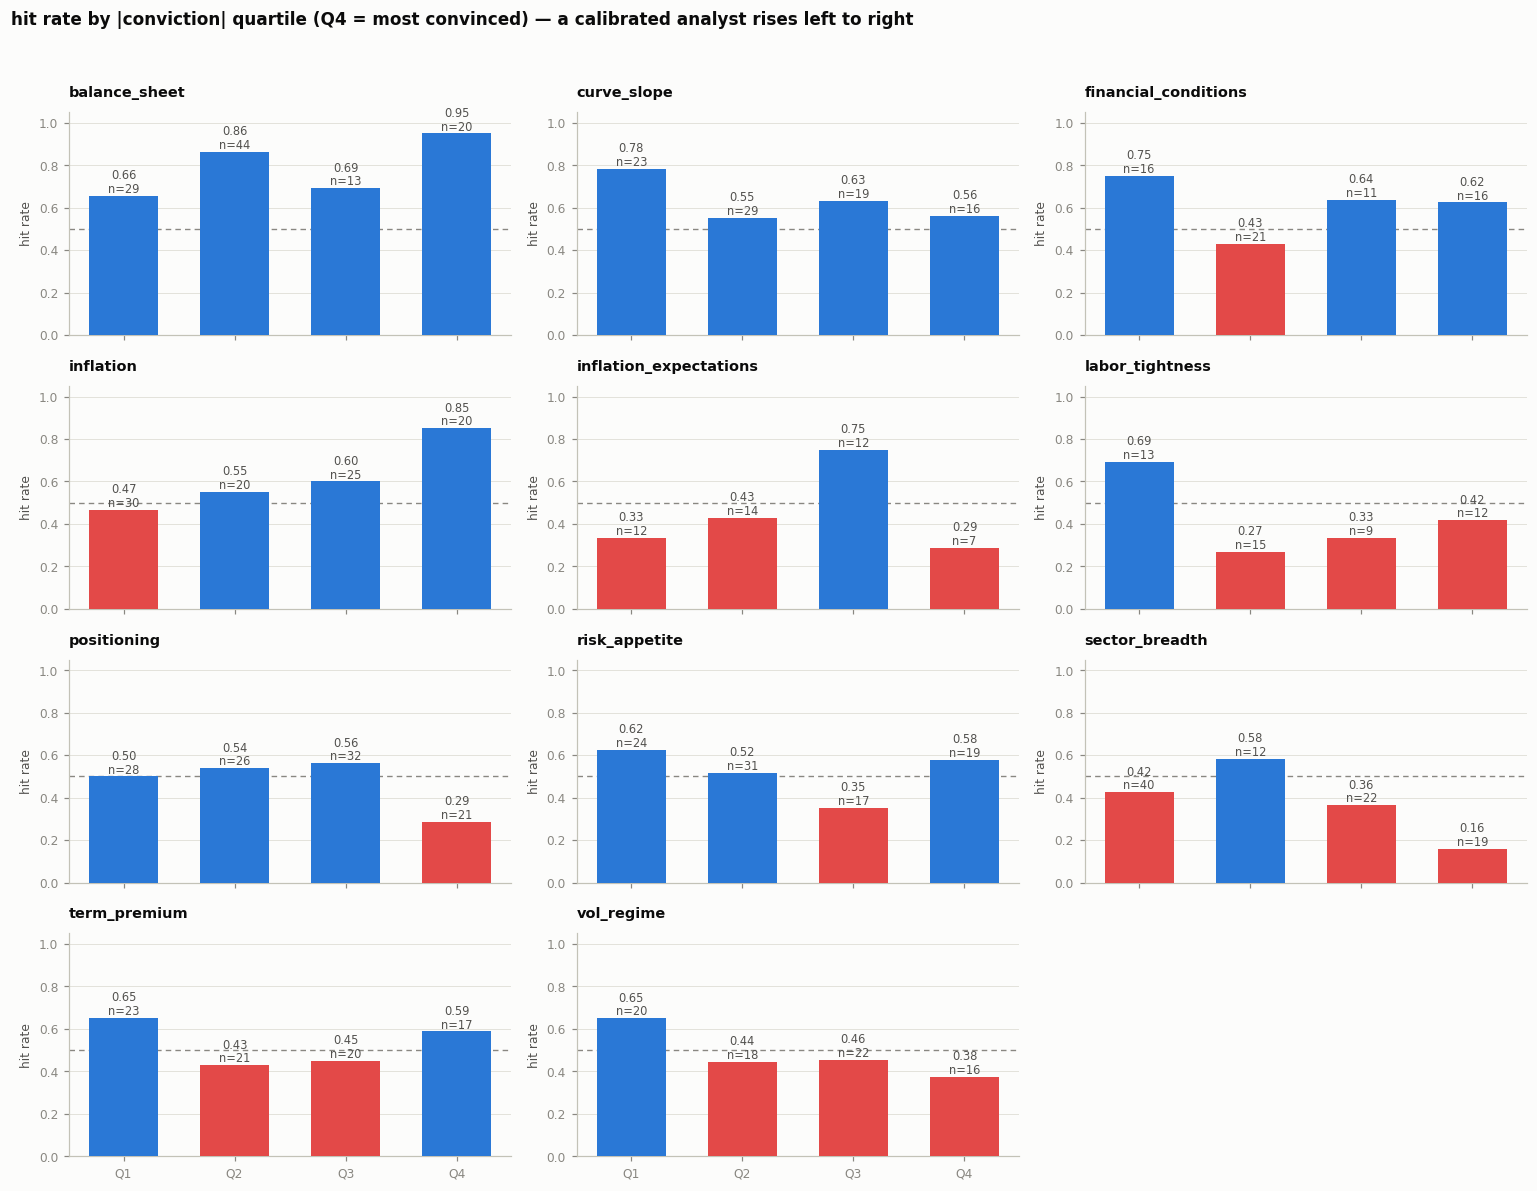

In [14]:
print(f"=== 2. conviction monotonicity ({ARM}) — is the ladder ordered? ===\n")
fig, axes = plt.subplots(4, 3, figsize=(14, 11), sharex=True)
axes = axes.ravel()
for ax, drv in zip(axes, DRIVERS):
    b = D.conviction_buckets(runs[(drv,ARM)].signed.dropna(),
                             runs[(drv,ARM)].level.dropna(), q=4)
    if b.empty: ax.axis("off"); continue
    hr = b["hit_rate"].to_numpy()
    ax.bar(range(len(b)), hr, color=[POS if v>=0.5 else NEG for v in hr],
           width=0.62, zorder=3)
    ax.axhline(0.5, color=MUTED, lw=0.9, ls=(0,(4,3)), zorder=2)
    for i,(v,nn) in enumerate(zip(hr, b["n"])):
        ax.text(i, v+0.015, f"{v:.2f}\nn={nn}", ha="center", fontsize=7.5, color=INK2)
    ax.set_xticks(range(len(b))); ax.set_xticklabels(b["bucket"], fontsize=8)
    ax.set_ylim(0,1.05); ax.set_title(drv, fontsize=9.5, color=INK)
    ax.set_ylabel("hit rate", fontsize=8); ax.tick_params(labelsize=8)
    clean(ax, xgrid=False)
for ax in axes[len(DRIVERS):]: ax.axis("off")
fig.suptitle("hit rate by |conviction| quartile (Q4 = most convinced) — "
             "a calibrated analyst rises left to right",
             x=0.005, ha="left", fontsize=11, color=INK, weight="600")
plt.tight_layout(rect=(0,0,1,0.96)); plt.show()

In [15]:
print(f"=== 5. regime IC ({ARM}) ===")
rg = pd.concat([D.regime_ic(runs[(d,ARM)].signed.dropna(), runs[(d,ARM)].level.dropna())
                .assign(driver=d) for d in DRIVERS])
rg["period"] = rg["from"].str[:4] + "–" + rg["to"].str[:4]
display(rg.pivot_table(index="driver", columns="period", values="ic").round(3))

print("\n=== 6. arm disagreement — where two arms split, who was right? ===")
pairs = [("none","anon_cue"), ("anon_cue","anon_full"), ("anon_full","plain")]
dis = []
for d in DRIVERS:
    sig = {a: runs[(d,a)].signed.dropna() for a in ARMS if (d,a) in runs}
    for a,b in pairs:
        if a not in sig or b not in sig: continue
        r = D.arm_disagreement(sig, runs[(d,a)].level.dropna(), a, b)
        dis.append({"driver":d, "pair":f"{a} vs {b}", "n_disagree":r["n_disagree"],
                    "share":r["share_of_sample"], f"first_right":r.get(f"{a}_right")})
DIS = pd.DataFrame(dis).rename(columns={"first_right":"left arm right"})
display(DIS.pivot_table(index="driver", columns="pair", values="left arm right").round(3))
print("  >0.5 means the LEFT arm of the pair won the disagreements. n_disagree matters:")
display(DIS.pivot_table(index="driver", columns="pair", values="n_disagree"))

=== 5. regime IC (anon_cue) ===


period,2016–2020,2020–2022,2022–2026
driver,,,
balance_sheet,0.526,0.321,0.393
curve_slope,0.149,0.443,0.225
financial_conditions,0.049,0.357,0.181
inflation,0.229,0.229,0.202
inflation_expectations,0.132,0.244,-0.215
labor_tightness,0.130,0.184,-0.149
positioning,-0.027,0.114,-0.283
risk_appetite,0.057,0.318,0.084
sector_breadth,-0.206,-0.249,-0.091



=== 6. arm disagreement — where two arms split, who was right? ===


pair,anon_cue vs anon_full,anon_full vs plain,none vs anon_cue
driver,,,
balance_sheet,0.750,0.500,0.500
curve_slope,0.650,0.529,0.375
financial_conditions,0.588,0.385,0.533
inflation,0.400,0.643,0.654
inflation_expectations,0.750,0.333,0.000
labor_tightness,0.250,0.500,0.600
positioning,0.643,0.429,0.481
risk_appetite,0.692,0.250,0.286
sector_breadth,0.588,0.389,0.353


  >0.5 means the LEFT arm of the pair won the disagreements. n_disagree matters:


pair,anon_cue vs anon_full,anon_full vs plain,none vs anon_cue
driver,,,
balance_sheet,4.0,2.0,2.0
curve_slope,20.0,17.0,16.0
financial_conditions,17.0,13.0,15.0
inflation,20.0,14.0,26.0
inflation_expectations,4.0,6.0,2.0
labor_tightness,4.0,4.0,5.0
positioning,14.0,21.0,27.0
risk_appetite,13.0,12.0,14.0
sector_breadth,17.0,18.0,17.0


## Caveats that travel with every number above

- **Never pool an arm delta across drivers.** Excerpt coverage runs from 0% (`positioning`)
  to 100% (`inflation`), so a pooled arm effect mostly reports which drivers got text.
- **`positioning`'s `anon_cue` is its `none` arm** — zero excerpt coverage by design,
  because the FOMC does not discuss investor positioning.
- **`financial_conditions` cue coverage is 56%**, so a null there is part artifact.
- **`anon_cue` has no diff structure** and is *not* comparable to the pre-2026 `cue` legs.
- **`plain` is a leak probe.** Its IC never belongs in an analyst results table.
- **44 IC cells and 55 correlation pairs** were scored; expect ~2 and ~3 at |t|≥2 by chance.
- **The post-2024 slice is ~17 observations.** Sign agreement and hit rate only — no
  t-statistic, and `p_approx` is invalid at that n.
- **`curve_slope` and `risk_appetite` are a known duplicate pair** (both graded on the 2s10s
  slope; outcome correlation +0.951).